# PRACTICE SESSION - 4

**NAME:** ABISHEK JS  
**REG NO:** RA2411026010307  
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">

### TITLE:
## IMPLEMENT BAYESIAN LOGISTIC REGRESSION AND SVM FOR CLASSIFICATION
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">

### AIM
To implement Bayesian Logistic Regression and Support Vector Machine (SVM) on the Cancer dataset, evaluate their classification performance, and compare both models.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">

### OBJECTIVES
1. Load and explore the Cancer dataset (`cancer.csv`).
2. Convert the target `diagnosis` into a binary target (`0 = Benign (No Cancer)`, `1 = Malignant (Cancer)`).
3. Preprocess the data using train-test split (80:20) and feature scaling (`StandardScaler`).
4. Build and train a Bayesian Logistic Regression model using `PyMC`.
5. Train a Support Vector Machine (SVM) classifier with an `RBF` kernel.
6. Evaluate and compare both models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">

### 1. INTRODUCTION
Classification is a machine learning technique used to predict a category or class for given input data. In this practice session, we classify whether a patient sample indicates Cancer (`Class 1: Malignant`) or No Cancer (`Class 0: Benign`).

We compare two models:
* **Bayesian Logistic Regression:** A probabilistic model that treats weights as probability distributions, giving us both predictions and uncertainty estimates.
* **Support Vector Machine (SVM):** A popular machine learning model that finds the best decision boundary (hyperplane) to separate the two classes.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


## 2. THEORY

### 2.1 Logistic Regression
* Standard Logistic Regression predicts the probability $P(y=1)$ using the **sigmoid function**:
  $$P(y=1) = \frac{1}{1 + e^{-z}}$$
  where $z = w_1 x_1 + w_2 x_2 + \dots + b$.
* The sigmoid function maps any real-valued number into a probability range between 0 and 1.
* If $P(y=1) \ge 0.5$, we predict **Class 1 (Malignant / Cancer)**; otherwise, **Class 0 (Benign / No Cancer)**.

### 2.2 Bayesian Logistic Regression
* In standard logistic regression, we find a single fixed point estimate for each weight coefficient.
* In **Bayesian Logistic Regression**, we treat weights as probability distributions:
  1. **Prior:** Our prior belief about weights before observing data (e.g., Normal distribution $\mathcal{N}(0, \sigma^2)$).
  2. **Likelihood:** The probability of observing data given the weights (Bernoulli distribution).
  3. **Posterior:** The updated distribution of weights after learning from data using Bayes' Theorem:
     $$\text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$
* Because computing the exact posterior analytically is intractable, we use MCMC (Markov Chain Monte Carlo) with the **NUTS (No-U-Turn Sampler)** to sample from the posterior distribution.

### 2.3 Support Vector Machine (SVM)
* SVM finds the optimal decision hyperplane that separates the classes with maximum margin (maximum distance to nearest data points).
* The data points closest to the decision boundary are called **Support Vectors**.
* We use the **Radial Basis Function (RBF) Kernel** to model complex non-linear decision boundaries.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


## 3. DATASET DESCRIPTION

We use the Cancer dataset (`cancer.csv`), which contains 569 patient records and 30 continuous clinical features derived from digitized images of cell nuclei:

* **diagnosis:** Target variable (`M` = Malignant, `B` = Benign)
* **Mean Features:** `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`
* **Standard Error (SE) Features:** `radius_se`, `texture_se`, `perimeter_se`, `area_se`, `smoothness_se`, `compactness_se`, `concavity_se`, `concave points_se`, `symmetry_se`, `fractal_dimension_se`
* **Worst (Largest) Features:** `radius_worst`, `texture_worst`, `perimeter_worst`, `area_worst`, `smoothness_worst`, `compactness_worst`, `concavity_worst`, `concave points_worst`, `symmetry_worst`, `fractal_dimension_worst`

**Binary Target Encoding:**
* `0`: Benign (No Cancer)
* `1`: Malignant (Cancer)
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


## 4. IMPORTING REQUIRED LIBRARIES

**Explanation:**
We import pandas and numpy for data handling, matplotlib and seaborn for plotting, scikit-learn for preprocessing and SVM, and PyMC & ArviZ for Bayesian probabilistic modeling.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [53]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import pymc as pm
import arviz as az

# Plot formatting
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("All libraries imported successfully!")
print("PyMC version   :", pm.__version__)
print("ArviZ version  :", az.__version__)
print("NumPy version  :", np.__version__)
print("Pandas version :", pd.__version__)


All libraries imported successfully!
PyMC version   : 6.3.1
ArviZ version  : 1.3.0
NumPy version  : 2.4.6
Pandas version : 3.0.3


## 5. LOADING THE DATASET

**Explanation:**
We load the dataset `cancer.csv` into a pandas DataFrame and display the first 5 rows.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [54]:
# Load the dataset
df = pd.read_csv("cancer.csv")

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
df.head()


Dataset loaded successfully!

First 5 rows:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,M,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,M,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,M,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,M,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## 6. EXPLORATORY DATA ANALYSIS (EDA)

### 6.1 - 6.4: Dataset Shape, Columns, Info & Missing Values

**Explanation:**
We check the size of the dataset, column names, data types, missing values, and the original target class counts.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [55]:
# 1. Dataset Shape
print("Shape of dataset (rows, columns):", df.shape)

# 2. Column names
print("\nColumns:", df.columns.tolist())

# 3. Dataset Info
print("\nDataset Info:")
df.info()

# 4. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 5. Original target counts
print("\nOriginal 'diagnosis' class counts:")
print(df["diagnosis"].value_counts())


Shape of dataset (rows, columns): (569, 31)

Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   per

### 6.5: Creating Binary Target & Class Distribution Plot

**Explanation:**
We convert the target `diagnosis` into binary values (`0 = Benign`, `1 = Malignant`) using `LabelEncoder` and plot a bar chart with patient counts and percentage labels on top of each bar.


Binary target counts (0 = Benign, 1 = Malignant):
diagnosis
0    357
1    212
Name: count, dtype: int64


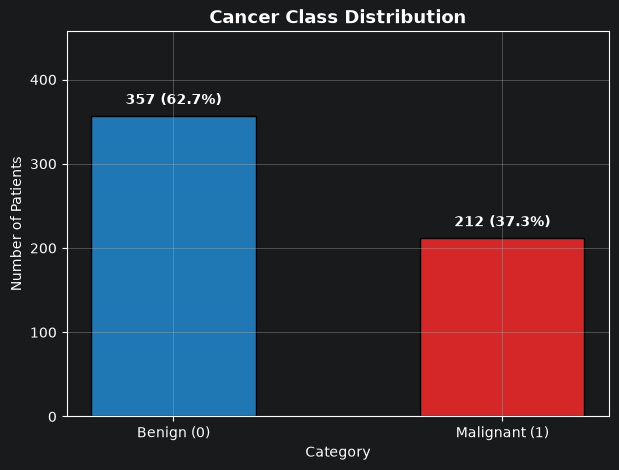

In [56]:
# Encode target variable: B -> 0 (Benign), M -> 1 (Malignant)
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

print("Binary target counts (0 = Benign, 1 = Malignant):")
print(df["diagnosis"].value_counts().sort_index())

# Plot class distribution
plt.figure(figsize=(7, 5))
counts = df["diagnosis"].value_counts().sort_index()
bars = plt.bar(["Benign (0)", "Malignant (1)"], counts, 
               color=["#1f77b4", "#d62728"], edgecolor="black", width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 10, 
             f"{yval} ({yval / len(df) * 100:.1f}%)", 
             ha="center", va="bottom", fontweight="bold")

plt.title("Cancer Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Number of Patients")
plt.ylim(0, max(counts) + 100)
plt.show()


### 6.6: Descriptive Statistics

**Explanation:**
We calculate basic summary statistics (count, mean, standard deviation, min, median, max) for numerical features.


In [57]:
# Summary statistics
print("Descriptive Statistics:")
df.describe()


Descriptive Statistics:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,0.372583,-1.373633e-16,7.492542e-17,-1.248757e-16,-2.122887e-16,-8.116921e-16,1.873136e-16,4.995028e-17,-3.746271e-17,1.748260e-16,...,-8.491548e-16,1.248757e-17,-3.621395e-16,0.000000,-2.247763e-16,-3.496520e-16,7.492542e-17,2.497514e-16,2.747265e-16,-5.619407e-16
std,0.483918,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,0.000000,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,0.000000,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,0.000000,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,1.000000,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,1.000000,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


### 6.7: Radius Mean Distribution by Target (Box Plot)

**Explanation:**
We use a box plot to compare patient `radius_mean` between healthy/benign patients and cancer/malignant patients.


<Figure size 800x500 with 0 Axes>

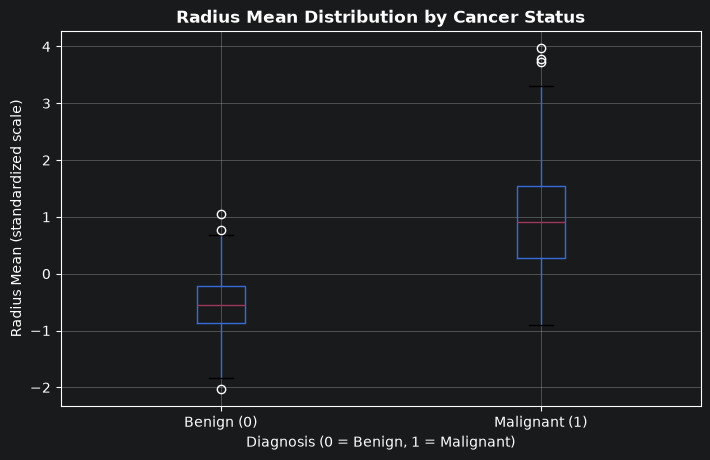

In [58]:
# Box plot of Radius Mean by Target
plt.figure(figsize=(8, 5))
df.boxplot(column="radius_mean", by="diagnosis", grid=True)
plt.title("Radius Mean Distribution by Cancer Status", fontsize=12, fontweight="bold")
plt.suptitle("")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Radius Mean (standardized scale)")
plt.xticks([1, 2], ["Benign (0)", "Malignant (1)"])
plt.show()


### 6.8: Correlation Heatmap

**Explanation:**
We plot a correlation heatmap to see how mean clinical features correlate with cancer diagnosis.


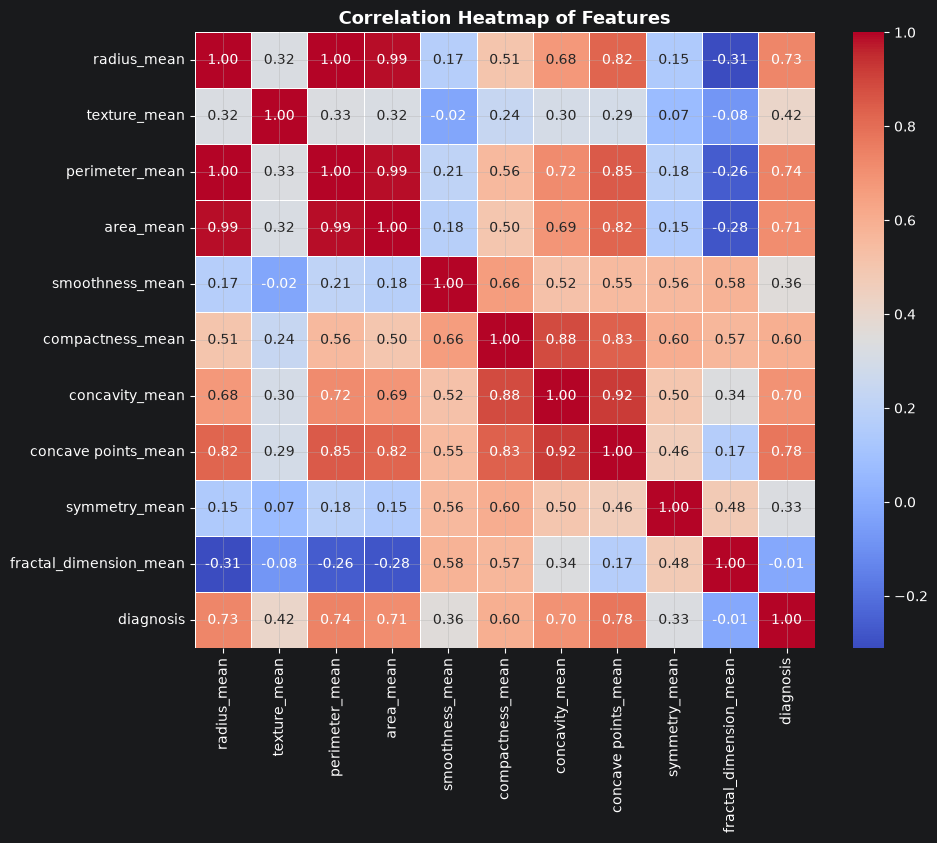

In [59]:
# Correlation Heatmap for Mean Features
mean_cols = [col for col in df.columns if "mean" in col] + ["diagnosis"]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=13, fontweight="bold")
plt.show()


## 7. DATA PREPROCESSING

### 7.1 & 7.2: Separate Features (X) and Target (y)

**Explanation:**
We separate input features into X and the target column into y, dropping `diagnosis` from X.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [60]:
# Separate features (X) and target (y)
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Features shape (X):", X.shape)
print("Target shape (y)  :", y.shape)


Features shape (X): (569, 30)
Target shape (y)  : (569,)


### 7.3 - 7.5: Identify Feature Types & Encoding

**Explanation:**
We confirm all predictor columns in X are continuous numerical features.


In [61]:
# Identify categorical and numerical features
categorical_columns = X.select_dtypes(include=["object", "category", "str"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns count:", len(numerical_columns))


Categorical columns: []
Numerical columns count: 30


### 7.6: Stratified Train-Test Split (80:20)

**Explanation:**
We split data into 80% training and 20% test sets using `stratify=y` so both sets have the same class ratio.


In [62]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (455, 30)
X_test shape : (114, 30)
y_train shape: (455,)
y_test shape : (114,)


### 7.7: Feature Scaling with StandardScaler

**Explanation:**
We standardize features to mean 0 and standard deviation 1. We fit on `X_train` only to prevent data leakage.


In [63]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape    :", X_test_scaled.shape)


Scaled training shape: (455, 30)
Scaled test shape    : (114, 30)


## 8. BAYESIAN LOGISTIC REGRESSION

### 8.1 - 8.6: Create Bayesian Model in PyMC

**Explanation:**
We define the Bayesian model:
* **Priors:** Normal distributions $\mathcal{N}(0, 2^2)$ for intercept and coefficients.
* **Linear Predictor:** $\text{intercept} + X \cdot \text{coefficients}$.
* **Sigmoid Link:** Converts linear predictor to probability (between 0 and 1).
* **Likelihood:** Bernoulli distribution for binary observations.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [64]:
# 1. Define model coordinates
coords = {
    "feature": X_train.columns.tolist()
}

# 2. Build Bayesian Logistic Regression Model
with pm.Model(coords=coords) as bayesian_logistic_model:
    # Prior for intercept
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    # Prior for feature coefficients
    coefficients = pm.Normal("coefficients", mu=0, sigma=2, dims="feature")

    # Linear predictor
    linear_predictor = intercept + pm.math.dot(X_train_scaled, coefficients)

    # Sigmoid function
    probability = pm.Deterministic("probability", pm.math.sigmoid(linear_predictor))

    # Likelihood
    observed = pm.Bernoulli("observed", p=probability, observed=y_train.to_numpy())

print("Bayesian Logistic Regression model created successfully!")


Bayesian Logistic Regression model created successfully!


## 9. BAYESIAN SAMPLING (NUTS)

**Explanation:**
We sample the posterior distribution using PyMC's No-U-Turn Sampler (NUTS) with 4 chains and 1,000 draws per chain.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [65]:
# Sample the posterior using NUTS
with bayesian_logistic_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

print("\nSampling completed successfully!")
print("Total posterior samples collected:", 
      trace.posterior.dims["chain"] * trace.posterior.dims["draw"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, coefficients]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.



Sampling completed successfully!
Total posterior samples collected: 4000


## 10. BAYESIAN MODEL SUMMARY

**Explanation:**
We generate the posterior summary table using ArviZ.

**Viva Key Points:**
* **mean:** Average estimated weight.
* **r_hat ($\hat{R}$) $\approx 1.00$:** Proves all 4 chains converged properly.
* **ess_bulk > 400:** High effective sample size means reliable sampling.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [66]:
# Generate posterior summary table
summary_df = az.summary(
    trace,
    var_names=["intercept", "coefficients"],
    ci_prob=0.95
)

print("ArviZ Posterior Summary (95% Credible Intervals):")
summary_df


ArviZ Posterior Summary (95% Credible Intervals):


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.21,0.69,-1.1,1.6,5841,3025,1.00,0.009,0.0064
coefficients[radius_mean],0.27,1.74,-3.2,3.7,6533,3360,1.00,0.022,0.015
coefficients[texture_mean],0.41,0.94,-1.5,2.2,5181,3550,1.00,0.013,0.009
coefficients[perimeter_mean],0.34,1.72,-3,3.7,8056,3222,1.00,0.019,0.013
coefficients[area_mean],0.57,1.83,-3,4.2,7293,2710,1.00,0.021,0.016
coefficients[smoothness_mean],0.79,1.07,-1.3,2.9,5427,2813,1.00,0.015,0.01
coefficients[compactness_mean],-1.48,1.5,-4.4,1.5,6043,3079,1.00,0.019,0.014
coefficients[concavity_mean],1.65,1.58,-1.5,4.8,7136,3390,1.00,0.019,0.013
coefficients[concave points_mean],1.99,1.58,-1,5.1,6969,2959,1.00,0.019,0.014
coefficients[symmetry_mean],-0.66,0.82,-2.3,0.93,5887,3112,1.00,0.011,0.0076


## 11. BAYESIAN LOGISTIC REGRESSION PREDICTION

**Explanation:**
We calculate predicted probabilities for the test set by averaging predictions across all 4,000 posterior draws. If probability $\ge 0.5$, we predict 1; otherwise 0.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [67]:
# 1. Extract posterior samples
post_intercept = trace.posterior["intercept"].values.reshape(-1)
post_coefficients = trace.posterior["coefficients"].values.reshape(-1, X_train_scaled.shape[1])

# 2. Compute logits and probabilities for test set
logits_test = post_intercept[None, :] + np.dot(X_test_scaled, post_coefficients.T)
prob_samples_test = 1.0 / (1.0 + np.exp(-logits_test))

# 3. Calculate mean probability and binary class predictions
bayes_pred_prob = prob_samples_test.mean(axis=1)
bayes_pred_class = (bayes_pred_prob >= 0.5).astype(int)

print("Bayesian predictions generated successfully!")
print("Predicted counts on test set -> Class 0:", (bayes_pred_class == 0).sum(), 
      ", Class 1:", (bayes_pred_class == 1).sum())


Bayesian predictions generated successfully!
Predicted counts on test set -> Class 0: 73 , Class 1: 41


## 12. BAYESIAN LOGISTIC REGRESSION EVALUATION

### 12.1: Metric Scores

**Explanation:**
We calculate Accuracy, Precision, Recall, F1 Score, and ROC-AUC for Bayesian Logistic Regression on the test set.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [68]:
# Calculate BLR evaluation metrics
bayes_accuracy = accuracy_score(y_test, bayes_pred_class)
bayes_precision = precision_score(y_test, bayes_pred_class)
bayes_recall = recall_score(y_test, bayes_pred_class)
bayes_f1 = f1_score(y_test, bayes_pred_class)
bayes_roc_auc = roc_auc_score(y_test, bayes_pred_prob)

print("=" * 55)
print(" BAYESIAN LOGISTIC REGRESSION - EVALUATION METRICS")
print("=" * 55)
print(f"Accuracy  : {bayes_accuracy:.4f} ({bayes_accuracy * 100:.2f}%)")
print(f"Precision : {bayes_precision:.4f} ({bayes_precision * 100:.2f}%)")
print(f"Recall    : {bayes_recall:.4f} ({bayes_recall * 100:.2f}%)")
print(f"F1 Score  : {bayes_f1:.4f} ({bayes_f1 * 100:.2f}%)")
print(f"ROC-AUC   : {bayes_roc_auc:.4f} ({bayes_roc_auc * 100:.2f}%)")
print("=" * 55)


 BAYESIAN LOGISTIC REGRESSION - EVALUATION METRICS
Accuracy  : 0.9737 (97.37%)
Precision : 0.9756 (97.56%)
Recall    : 0.9524 (95.24%)
F1 Score  : 0.9639 (96.39%)
ROC-AUC   : 0.9940 (99.40%)


### 12.2: Confusion Matrix & Classification Report

**Explanation:**
We display the Confusion Matrix (True Negatives, False Positives, False Negatives, True Positives) and the classification report for Bayesian Logistic Regression.


Confusion Matrix:
[[71  1]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98        72
Malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



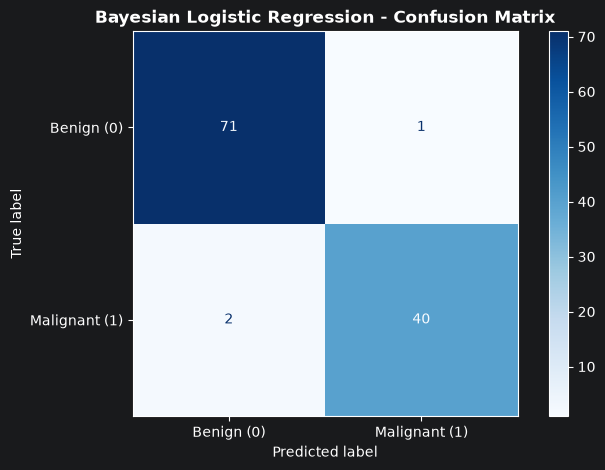

In [69]:
# Confusion matrix and report for BLR
bayes_cm = confusion_matrix(y_test, bayes_pred_class)
print("Confusion Matrix:")
print(bayes_cm)

print("\nClassification Report:")
print(classification_report(y_test, bayes_pred_class, 
                            target_names=["Benign (0)", "Malignant (1)"]))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=bayes_cm, 
                              display_labels=["Benign (0)", "Malignant (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Bayesian Logistic Regression - Confusion Matrix", fontweight="bold")
plt.grid(False)
plt.show()


## 13. SUPPORT VECTOR MACHINE (SVM) CLASSIFICATION

**Explanation:**
We train an SVM classifier with an RBF kernel (`SVC(kernel='rbf', probability=True, random_state=42)`) using the same scaled training data and predict on the test set.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [70]:
# Initialize and train SVM classifier
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

# Predict classes and probabilities
svm_pred_class = svm_model.predict(X_test_scaled)
svm_pred_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM model trained successfully!")
print("Number of support vectors:", svm_model.n_support_.sum())


SVM model trained successfully!
Number of support vectors: 107


## 14. SVM EVALUATION

### 14.1: Metric Scores

**Explanation:**
We calculate Accuracy, Precision, Recall, F1 Score, and ROC-AUC for the SVM classifier on the test set.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [71]:
# Calculate SVM evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_pred_class)
svm_precision = precision_score(y_test, svm_pred_class)
svm_recall = recall_score(y_test, svm_pred_class)
svm_f1 = f1_score(y_test, svm_pred_class)
svm_roc_auc = roc_auc_score(y_test, svm_pred_prob)

print("=" * 55)
print(" SUPPORT VECTOR MACHINE (SVM) - EVALUATION METRICS")
print("=" * 55)
print(f"Accuracy  : {svm_accuracy:.4f} ({svm_accuracy * 100:.2f}%)")
print(f"Precision : {svm_precision:.4f} ({svm_precision * 100:.2f}%)")
print(f"Recall    : {svm_recall:.4f} ({svm_recall * 100:.2f}%)")
print(f"F1 Score  : {svm_f1:.4f} ({svm_f1 * 100:.2f}%)")
print(f"ROC-AUC   : {svm_roc_auc:.4f} ({svm_roc_auc * 100:.2f}%)")
print("=" * 55)


 SUPPORT VECTOR MACHINE (SVM) - EVALUATION METRICS
Accuracy  : 0.9737 (97.37%)
Precision : 1.0000 (100.00%)
Recall    : 0.9286 (92.86%)
F1 Score  : 0.9630 (96.30%)
ROC-AUC   : 0.9947 (99.47%)


### 14.2: Confusion Matrix & Classification Report

**Explanation:**
We display the Confusion Matrix and Classification Report for SVM.


SVM Confusion Matrix:
[[72  0]
 [ 3 39]]

SVM Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



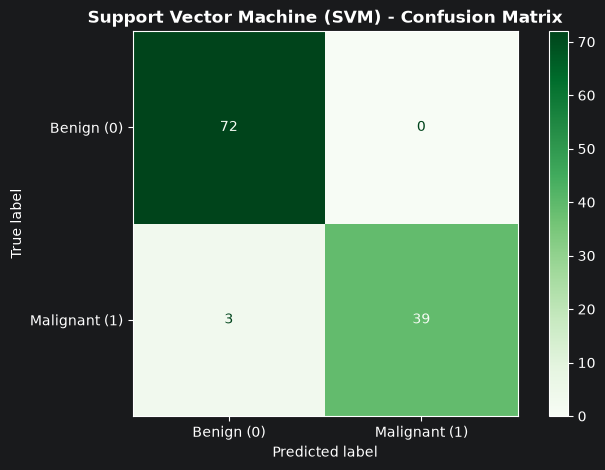

In [72]:
# Confusion matrix and report for SVM
svm_cm = confusion_matrix(y_test, svm_pred_class)
print("SVM Confusion Matrix:")
print(svm_cm)

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred_class, 
                            target_names=["Benign (0)", "Malignant (1)"]))

# Plot Confusion Matrix
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_cm, 
                                  display_labels=["Benign (0)", "Malignant (1)"])
disp_svm.plot(cmap="Greens", values_format="d")
plt.title("Support Vector Machine (SVM) - Confusion Matrix", fontweight="bold")
plt.grid(False)
plt.show()


## 15. MODEL COMPARISON

**Explanation:**
We create a comparison table showing Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Average Score for both models.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [73]:
# Model Comparison DataFrame
comparison_data = {
    "Model": ["Bayesian Logistic Regression", "Support Vector Machine (SVM)"],
    "Accuracy": [bayes_accuracy, svm_accuracy],
    "Precision": [bayes_precision, svm_precision],
    "Recall": [bayes_recall, svm_recall],
    "F1 Score": [bayes_f1, svm_f1],
    "ROC-AUC": [bayes_roc_auc, svm_roc_auc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df["Average Score"] = comparison_df[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].mean(axis=1)

print("=" * 80)
print("                            MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 80)


                            MODEL COMPARISON SUMMARY
                       Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Average Score
Bayesian Logistic Regression    0.9737     0.9756  0.9524    0.9639   0.9940         0.9719
Support Vector Machine (SVM)    0.9737     1.0000  0.9286    0.9630   0.9947         0.9720


## 16. CLASSIFICATION PERFORMANCE VISUALIZATION

**Explanation:**
We plot a grouped bar chart comparing all 5 evaluation metrics side-by-side with scores labeled on top of each bar.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


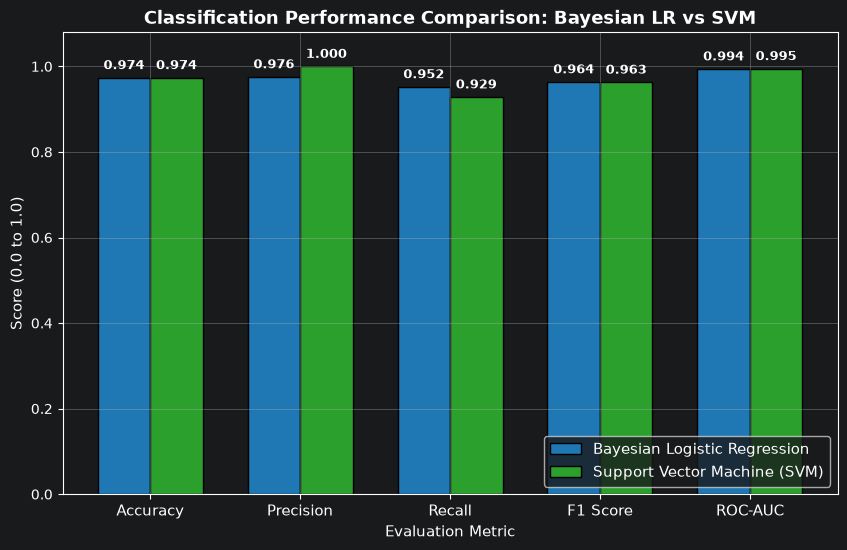

In [74]:
# Grouped Bar Chart
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
bayes_scores = [bayes_accuracy, bayes_precision, bayes_recall, bayes_f1, bayes_roc_auc]
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10, 6))
rects1 = plt.bar(x - width/2, bayes_scores, width, label="Bayesian Logistic Regression", color="#1f77b4", edgecolor="black")
rects2 = plt.bar(x + width/2, svm_scores, width, label="Support Vector Machine (SVM)", color="#2ca02c", edgecolor="black")

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(
            f"{height:.3f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

autolabel(rects1)
autolabel(rects2)

plt.title("Classification Performance Comparison: Bayesian LR vs SVM", fontsize=13, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=11)
plt.ylabel("Score (0.0 to 1.0)", fontsize=11)
plt.xticks(x, metrics_names, fontsize=11)
plt.ylim(0, 1.08)
plt.legend(loc="lower right", fontsize=11)
plt.show()


## 17. RESULT

**Explanation:**
We print the formal Result statement based strictly on the actual calculated numbers from our dataset.
<hr style="border: 0; border-top: 3px double #333; margin: 12px 0;">


In [75]:
# Formal Result Statement
bayes_avg = np.mean([bayes_accuracy, bayes_precision, bayes_recall, bayes_f1, bayes_roc_auc])
svm_avg = np.mean([svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc])

better_model = "Support Vector Machine (SVM)" if svm_avg > bayes_avg else "Bayesian Logistic Regression"
winner_avg = max(svm_avg, bayes_avg)
runner_up_avg = min(svm_avg, bayes_avg)

print("=" * 80)
print("                                 17. RESULT")
print("=" * 80)
print(f"1. Bayesian Logistic Regression:")
print(f"   - Accuracy       : {bayes_accuracy:.4f} ({bayes_accuracy*100:.2f}%)")
print(f"   - Precision      : {bayes_precision:.4f} ({bayes_precision*100:.2f}%)")
print(f"   - Recall         : {bayes_recall:.4f} ({bayes_recall*100:.2f}%)")
print(f"   - F1 Score       : {bayes_f1:.4f} ({bayes_f1*100:.2f}%)")
print(f"   - ROC-AUC        : {bayes_roc_auc:.4f} ({bayes_roc_auc*100:.2f}%)")
print(f"   - Average Score  : {bayes_avg:.4f} ({bayes_avg*100:.2f}%)")

print(f"\n2. Support Vector Machine (SVM):")
print(f"   - Accuracy       : {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"   - Precision      : {svm_precision:.4f} ({svm_precision*100:.2f}%)")
print(f"   - Recall         : {svm_recall:.4f} ({svm_recall*100:.2f}%)")
print(f"   - F1 Score       : {svm_f1:.4f} ({svm_f1*100:.2f}%)")
print(f"   - ROC-AUC        : {svm_roc_auc:.4f} ({svm_roc_auc*100:.2f}%)")
print(f"   - Average Score  : {svm_avg:.4f} ({svm_avg*100:.2f}%)")

print(f"\nConclusion of Result:")
print(f"Both models achieved excellent classification performance on the test set.")
print(f"Based on the average across all five metrics, {better_model} performed slightly better overall ({winner_avg*100:.2f}% vs {runner_up_avg*100:.2f}%).")
print(f"However, Bayesian Logistic Regression provides full posterior uncertainty intervals for every coefficient.")
print("=" * 80)


                                 17. RESULT
1. Bayesian Logistic Regression:
   - Accuracy       : 0.9737 (97.37%)
   - Precision      : 0.9756 (97.56%)
   - Recall         : 0.9524 (95.24%)
   - F1 Score       : 0.9639 (96.39%)
   - ROC-AUC        : 0.9940 (99.40%)
   - Average Score  : 0.9719 (97.19%)

2. Support Vector Machine (SVM):
   - Accuracy       : 0.9737 (97.37%)
   - Precision      : 1.0000 (100.00%)
   - Recall         : 0.9286 (92.86%)
   - F1 Score       : 0.9630 (96.30%)
   - ROC-AUC        : 0.9947 (99.47%)
   - Average Score  : 0.9720 (97.20%)

Conclusion of Result:
Both models achieved excellent classification performance on the test set.
Based on the average across all five metrics, Support Vector Machine (SVM) performed slightly better overall (97.20% vs 97.19%).
However, Bayesian Logistic Regression provides full posterior uncertainty intervals for every coefficient.
